# A5: Graph Neural Networks

In this lab, we implement **Graph Neural Networks (GNNs)** from scratch — without PyTorch Geometric — to understand message passing from the ground up.

| Model | Year | Key Idea |
|---|---|---|
| **GCN** | 2017 | Symmetric normalized aggregation: $\tilde{D}^{-1/2}\tilde{A}\tilde{D}^{-1/2}$ |
| **GAT** | 2018 | Attention-weighted aggregation — not all neighbors are equal |
| **GraphSAGE** | 2017 | Sample neighbors + concat aggregation — scales to billion-node graphs |
| **Graph Transformer** | 2020 | Self-attention on graphs with structural encodings |

**Application:** Genre prediction and recommendation on the MovieLens-100k dataset.

**Papers:** [GCN](https://arxiv.org/abs/1609.02907) · [GAT](https://arxiv.org/abs/1710.10903) · [GraphSAGE](https://arxiv.org/abs/1706.02216) · [Graphormer](https://arxiv.org/abs/2106.05234)

In [1]:
!pip install torch torchvision numpy matplotlib networkx scikit-learn tqdm scipy pandas

Defaulting to user installation because normal site-packages is not writeable


In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import scipy.sparse as sp
import pandas as pd
from sklearn.manifold import TSNE
from itertools import combinations
from tqdm import tqdm
import random, os, time
import urllib.request, zipfile

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

GENRE_COLS = ['unknown','Action','Adventure','Animation',"Children's",
              'Comedy','Crime','Documentary','Drama','Fantasy',
              'Film-Noir','Horror','Musical','Mystery','Romance',
              'Sci-Fi','Thriller','War','Western']

def set_seed(seed=42):
    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)

set_seed(42)

Using device: cuda


---
## Part 1: Understanding Graphs — Zachary's Karate Club

Before building a GNN, let's visualize **Zachary's Karate Club** — the "MNIST of GNNs". A social network of 34 members that split into two factions after a conflict. The goal: predict which group each member ends up in, using only the friendship edges.

**Why start here?** Small enough to visualize completely. Clear community structure. Every GNN paper benchmarks on it.

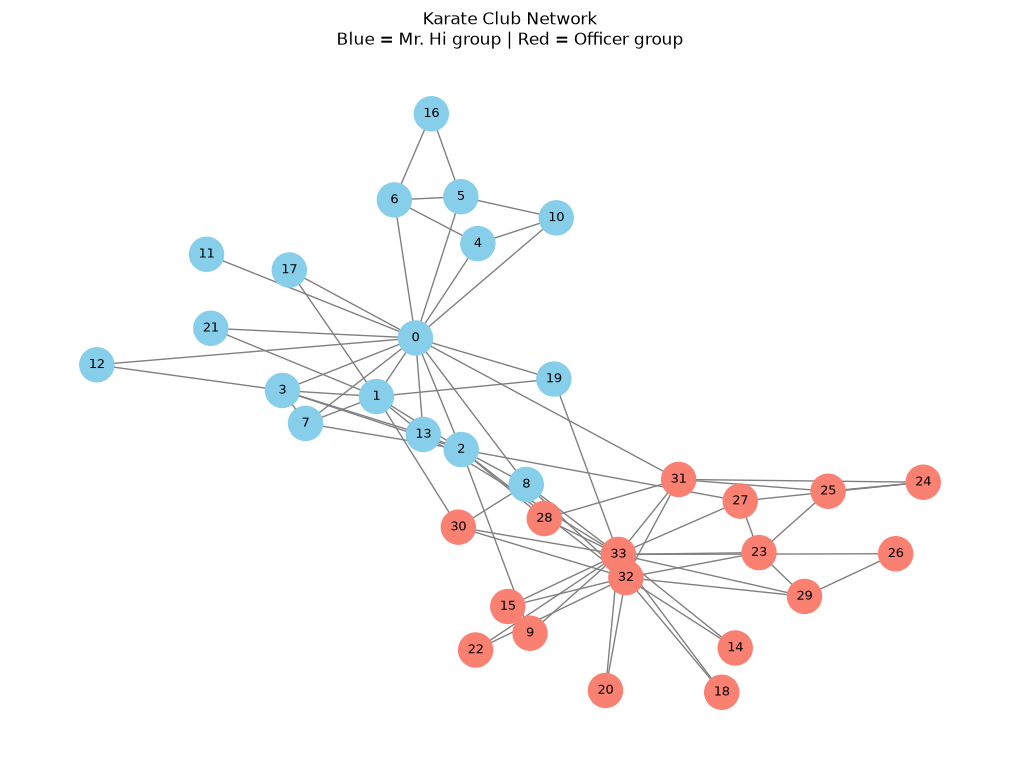

Nodes: 34
Edges: 78
Adjacency matrix shape: (34, 34)


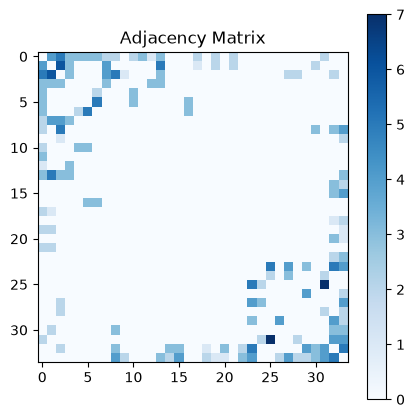

In [3]:
# Zachary's Karate Club graph
G_karate = nx.karate_club_graph()

# Visualize
plt.figure(figsize=(10, 7))
labels_karate = nx.get_node_attributes(G_karate, 'club')
colors = ['skyblue' if v == 'Mr. Hi' else 'salmon' for v in labels_karate.values()]
pos = nx.spring_layout(G_karate, seed=42)
nx.draw(G_karate, pos, node_color=colors, with_labels=True,
        node_size=600, font_size=9, edge_color='gray')
plt.title('Karate Club Network\nBlue = Mr. Hi group | Red = Officer group')
plt.axis('off'); plt.show()

print(f'Nodes: {G_karate.number_of_nodes()}')
print(f'Edges: {G_karate.number_of_edges()}')

# Convert to adjacency matrix
A = nx.to_numpy_array(G_karate)
print(f'Adjacency matrix shape: {A.shape}')

plt.figure(figsize=(5, 5))
plt.imshow(A, cmap='Blues')
plt.title('Adjacency Matrix')
plt.colorbar(); plt.show()

---
## Part 2: The MovieLens Co-rating Graph

Instead of Cora's citation network, we build a **movie co-rating graph** from MovieLens-100k:

- **1,682 nodes**: each node is a movie
- **Edges**: two movies are connected if **the same user rated both** (co-rated)
- **Node features**: genre one-hot vector (18 genres) + release year (normalized)
- **Labels**: primary genre (Action, Drama, Comedy, Thriller, ...)

**Why is this like Cora?**

```
Cora                          MovieLens Co-rating Graph
─────────────────────         ────────────────────────────
Paper node                →   Movie node
Cite edge (A cites B)     →   Co-rating edge (same user rated A & B)
Bag-of-words features     →   Genre + year features
7 research topic labels   →   Genre labels (18 classes)
```

The intuition is identical: movies that the **same users watch tend to be the same genre** — just like papers in the same field tend to cite each other. GCN can exploit this structure to predict genre even for movies with few ratings.

**Reference:** Harper & Konstan (2015). *The MovieLens Datasets*. ACM TIIS.
Dataset: https://grouplens.org/datasets/movielens/100k/

---

Movies: 1682
Feature dim: 20  (18 genres + 1 year)
Genre classes: 19
  unknown        :    2 movies
  Action         :  251 movies
  Adventure      :   60 movies
  Animation      :   35 movies
  Children's     :   48 movies
  Comedy         :  426 movies
  Crime          :   74 movies
  Documentary    :   49 movies
  Drama          :  531 movies
  Fantasy        :    1 movies
  Film-Noir      :   14 movies
  Horror         :   62 movies
  Musical        :    9 movies
  Mystery        :   20 movies
  Romance        :   31 movies
  Sci-Fi         :   15 movies
  Thriller       :   36 movies
  War            :    5 movies
  Western        :   13 movies

Building co-rating edges...
Edges (co-rating >= 5 users): 839,578

Split — Train: 267 | Val: 200 | Test: 500


/tmp/ipykernel_3984131/801295134.py:118: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.axis('off'); plt.tight_layout(); plt.show()


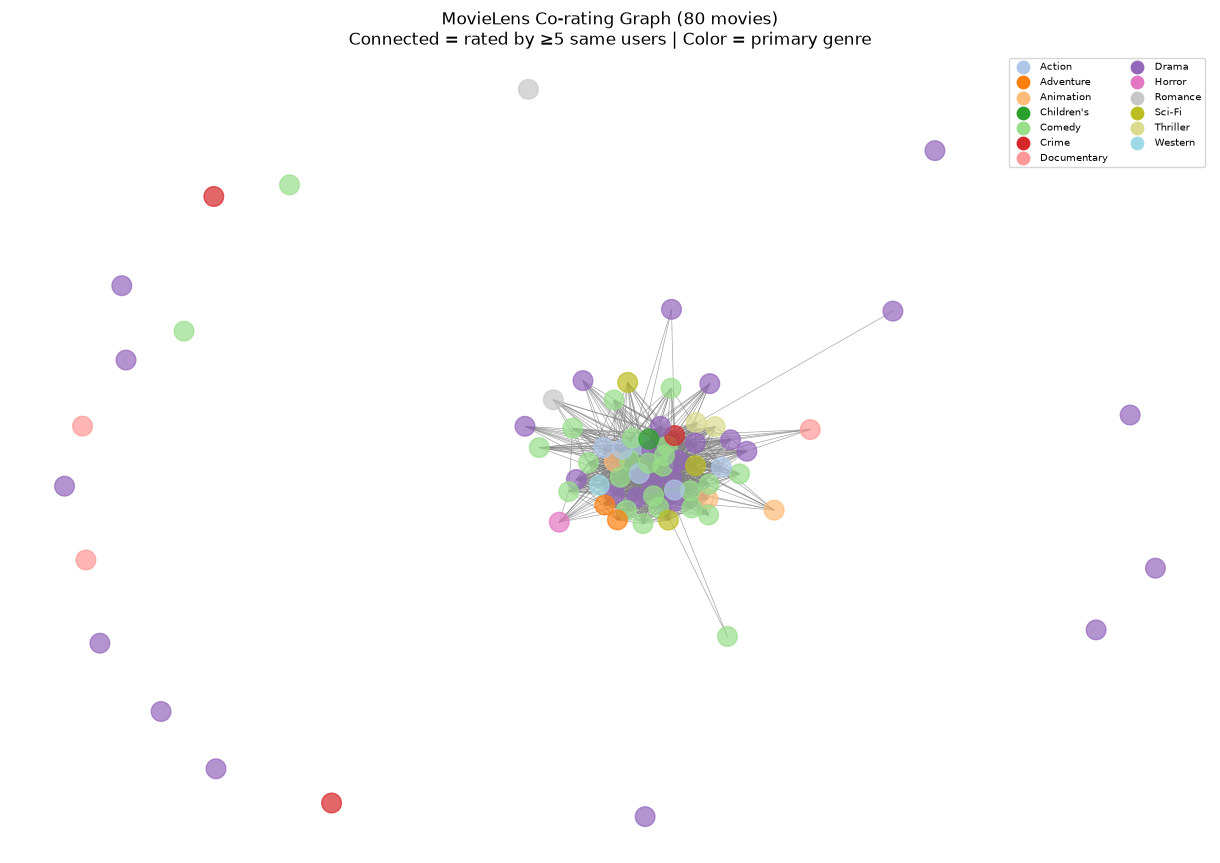

In [4]:
os.makedirs('data/movielens', exist_ok=True)

url = 'https://files.grouplens.org/datasets/movielens/ml-100k.zip'
if not os.path.exists('data/movielens/ml-100k/u.data'):
    print('Downloading MovieLens-100k...')
    urllib.request.urlretrieve(url, 'data/movielens/ml-100k.zip')
    with zipfile.ZipFile('data/movielens/ml-100k.zip') as z:
        z.extractall('data/movielens/')
    print('Done!')

ratings = pd.read_csv('data/movielens/ml-100k/u.data',
                      sep='\t', names=['user','item','rating','timestamp'])

movies = pd.read_csv('data/movielens/ml-100k/u.item', sep='|',
                     encoding='latin-1', header=None,
                     names=['item','title','release_date','video_date',
                            'imdb_url'] + GENRE_COLS)

# Node features: 18 genre flags + normalized release year
movies['year'] = movies['release_date'].str.extract(r'(\d{4})').astype(float)
movies['year'] = movies['year'].fillna(movies['year'].median())
movies['year_norm'] = (movies['year'] - movies['year'].min()) / (movies['year'].max() - movies['year'].min())

feat_cols = GENRE_COLS + ['year_norm']
movie_features = movies[feat_cols].fillna(0).values.astype(np.float32)

movie_ids = sorted(movies.item.unique())
mid2idx   = {m: i for i, m in enumerate(movie_ids)}
N_MOVIES  = len(movie_ids)

print(f'Movies: {N_MOVIES}')
print(f'Feature dim: {movie_features.shape[1]}  (18 genres + 1 year)')

# Labels: primary genre = first genre column that is 1
movies_indexed = movies.set_index('item').loc[movie_ids]
genre_matrix   = movies_indexed[GENRE_COLS].values

labels_raw = []
for row in genre_matrix:
    idx = np.argmax(row)
    if row[idx] == 0:
        idx = 0
    labels_raw.append(idx)

labels = np.array(labels_raw)
n_classes = len(set(labels))
print(f'Genre classes: {n_classes}')
for i, g in enumerate(GENRE_COLS):
    count = (labels == i).sum()
    if count > 0:
        print(f'  {g:15}: {count:4d} movies')

# Build co-rating graph: edge if >= 5 users rated both movies
MIN_COMMON = 5
user_movies = ratings.groupby('user')['item'].apply(list)

rows, cols = [], []
print('\nBuilding co-rating edges...')
for user, items in user_movies.items():
    valid = [mid2idx[m] for m in items if m in mid2idx]
    for a, b in combinations(valid, 2):
        rows.append(a); cols.append(b)
        rows.append(b); cols.append(a)

edge_df     = pd.DataFrame({'row': rows, 'col': cols})
edge_counts = edge_df.groupby(['row','col']).size().reset_index(name='count')
strong_edges = edge_counts[edge_counts['count'] >= MIN_COMMON]
print(f'Edges (co-rating >= {MIN_COMMON} users): {len(strong_edges):,}')

A_data = np.ones(len(strong_edges))
A_coo  = sp.coo_matrix((A_data,
                         (strong_edges['row'].values, strong_edges['col'].values)),
                        shape=(N_MOVIES, N_MOVIES))
A_movie = torch.FloatTensor(A_coo.toarray()).to(device)

X_movie = torch.FloatTensor(movie_features).to(device)
Y_movie = torch.LongTensor(labels).to(device)

# Train/val/test split: 20 per class for train
train_mask_m = torch.zeros(N_MOVIES, dtype=torch.bool)
val_mask_m   = torch.zeros(N_MOVIES, dtype=torch.bool)
test_mask_m  = torch.zeros(N_MOVIES, dtype=torch.bool)

for c in range(n_classes):
    idx = (Y_movie == c).nonzero(as_tuple=True)[0]
    if len(idx) >= 20:
        train_mask_m[idx[:20]] = True
    elif len(idx) > 0:
        train_mask_m[idx[:len(idx)//2]] = True

remaining = (~train_mask_m).nonzero(as_tuple=True)[0]
n_val = min(200, len(remaining)//2)
val_mask_m[remaining[:n_val]]          = True
test_mask_m[remaining[n_val:n_val+500]] = True

train_mask_m = train_mask_m.to(device)
val_mask_m   = val_mask_m.to(device)
test_mask_m  = test_mask_m.to(device)

print(f'\nSplit — Train: {train_mask_m.sum().item()} | Val: {val_mask_m.sum().item()} | Test: {test_mask_m.sum().item()}')

# Visualize graph sample
sample_idx  = np.random.choice(N_MOVIES, 80, replace=False)
A_sample    = A_coo.toarray()[np.ix_(sample_idx, sample_idx)]
G_sample    = nx.from_numpy_array(A_sample)
genre_colors = plt.cm.tab20(np.linspace(0, 1, n_classes))
node_colors  = [genre_colors[labels[i]] for i in sample_idx]

plt.figure(figsize=(12, 8))
pos = nx.spring_layout(G_sample, seed=42, k=0.4)
nx.draw(G_sample, pos, node_color=node_colors, node_size=200,
        with_labels=False, edge_color='gray', alpha=0.7, width=0.5)
handles = [plt.scatter([],[], c=[genre_colors[i]], s=80,
           label=GENRE_COLS[i]) for i in range(n_classes)
           if (labels[sample_idx] == i).any()]
plt.legend(handles=handles, loc='upper right', fontsize=7, ncol=2)
plt.title('MovieLens Co-rating Graph (80 movies)\nConnected = rated by ≥5 same users | Color = primary genre')
plt.axis('off'); plt.tight_layout(); plt.show()

---
## Part 3: GCN — Genre Prediction on MovieLens Co-rating Graph

### Message Passing Intuition

The key idea of all GNNs is **message passing**: update each node's representation by aggregating information from its neighbors.

```
Iteration 1:
  Node v gathers features from all 1-hop neighbors → h_v^(1)

Iteration 2:
  Node v gathers h^(1) from neighbors → h_v^(2)
  Now h_v^(2) contains info from 2-hop neighborhood!
```

### Why not just sum up the neighbors' features?

The simplest possible aggregation is $H' = A H W$ — just sum each node's neighbor features and transform. Try this on our movie graph and it breaks immediately:

> "A blockbuster like *Star Wars* gets co-rated with thousands of other movies — degree ~500 in our graph. A niche documentary might only share 5 raters with anything else — degree ~5. If we just sum neighbor features, *Star Wars*'s aggregated vector is summing over 500 movies' worth of signal, while the documentary sums over 5. The raw scale of the output is now dominated by **how popular the movie is**, not by what genres its neighbors actually are. High-degree nodes blow up; low-degree nodes barely move. The network ends up learning more about node popularity than node content."

That's the concrete problem GCN's normalization solves — not an abstract "treats neighbors equally" issue, but a literal scale-of-the-numbers issue caused by degree imbalance.

### GCN Formula (Kipf & Welling, 2017)

GCN simplifies spectral graph convolution to:

$$H^{(l+1)} = \sigma\left( \tilde{D}^{-1/2} \tilde{A} \tilde{D}^{-1/2} H^{(l)} W^{(l)} \right)$$

Where:
- $\tilde{A} = A + I$ — adjacency matrix **with self-loops** (a node also reads its own features!)
- $\tilde{D}$ — degree matrix of $\tilde{A}$
- $\tilde{D}^{-1/2} \tilde{A} \tilde{D}^{-1/2}$ — **symmetric normalization** to prevent nodes with many neighbors from dominating — it divides each node's aggregated sum by (roughly) its own degree and its neighbor's degree, so *Star Wars* and the niche documentary end up on a comparable numeric scale
- $W^{(l)}$ — learnable weight matrix

**Why self-loops?** Without self-loops, a node forgets its own features after each layer — it only aggregates neighbor info.

<img src="figures/message_passing.png" width="750"/>

*Message passing: each node aggregates features from its neighbors via a pooling function ρ, then updates its own representation via a learned function f.*

In [5]:
def normalize_adjacency(A):
    """D^{-1/2} (A+I) D^{-1/2} — symmetric normalized adjacency with self-loops."""
    A_tilde = A + torch.eye(A.size(0), device=A.device)
    D = A_tilde.sum(dim=1)
    D_inv_sqrt = torch.diag(D.pow(-0.5))
    return D_inv_sqrt @ A_tilde @ D_inv_sqrt


class GCNLayer(nn.Module):
    """Single GCN layer: H_new = Â H W"""
    def __init__(self, in_features, out_features):
        super().__init__()
        self.W = nn.Linear(in_features, out_features, bias=False)
        nn.init.xavier_uniform_(self.W.weight)

    def forward(self, H, A_norm):
        return A_norm @ self.W(H)


class GCN(nn.Module):
    """2-layer GCN for node classification."""
    def __init__(self, in_features, hidden_dim, n_classes, dropout=0.5):
        super().__init__()
        self.layer1  = GCNLayer(in_features, hidden_dim)
        self.layer2  = GCNLayer(hidden_dim, n_classes)
        self.dropout = nn.Dropout(dropout)

    def forward(self, X, A_norm):
        h = F.relu(self.layer1(X, A_norm))
        h = self.dropout(h)
        out = self.layer2(h, A_norm)
        return out, h

In [6]:
A_norm = normalize_adjacency(A_movie)

gcn = GCN(in_features=X_movie.shape[1], hidden_dim=64, n_classes=n_classes).to(device)
optimizer_gcn = torch.optim.Adam(gcn.parameters(), lr=0.01, weight_decay=5e-4)

gcn_train_acc, gcn_val_acc, gcn_epoch_times = [], [], []
t0_gcn = time.time()

for epoch in range(200):
    t_ep = time.time()
    gcn.train()
    logits, _ = gcn(X_movie, A_norm)
    loss = F.cross_entropy(logits[train_mask_m], Y_movie[train_mask_m])
    optimizer_gcn.zero_grad(); loss.backward(); optimizer_gcn.step()

    gcn.eval()
    with torch.no_grad():
        logits, _ = gcn(X_movie, A_norm)
        train_acc = (logits[train_mask_m].argmax(1) == Y_movie[train_mask_m]).float().mean().item()
        val_acc   = (logits[val_mask_m].argmax(1)   == Y_movie[val_mask_m]).float().mean().item()
    gcn_train_acc.append(train_acc)
    gcn_val_acc.append(val_acc)
    gcn_epoch_times.append(time.time() - t_ep)
    if (epoch+1) % 50 == 0:
        print(f'Epoch {epoch+1:3d} | Loss: {loss:.4f} | Train: {train_acc:.4f} | Val: {val_acc:.4f} | Time: {gcn_epoch_times[-1]:.2f}s')

gcn.eval()
with torch.no_grad():
    logits, gcn_embeddings = gcn(X_movie, A_norm)
    gcn_test_acc = (logits[test_mask_m].argmax(1) == Y_movie[test_mask_m]).float().mean().item()
print(f'\nGCN Test Accuracy: {gcn_test_acc*100:.2f}%')
print(f'Total training time: {time.time()-t0_gcn:.1f}s')

Epoch  50 | Loss: 2.5470 | Train: 0.1498 | Val: 0.3200 | Time: 0.00s
Epoch 100 | Loss: 2.4843 | Train: 0.1910 | Val: 0.4650 | Time: 0.00s
Epoch 150 | Loss: 2.4324 | Train: 0.2172 | Val: 0.4150 | Time: 0.00s
Epoch 200 | Loss: 2.3858 | Train: 0.2285 | Val: 0.4600 | Time: 0.00s

GCN Test Accuracy: 30.00%
Total training time: 0.9s


---
## Part 4: GAT — Graph Attention Network

### The Problem with GCN

GCN uses **fixed, symmetric weights** for aggregation. A node with 100 neighbors and a node with 2 neighbors are treated symmetrically — but not all neighbors are equally important!

### A concrete example before the math

> "Take a Drama movie that got co-rated with two neighbors: another Drama, and an Action movie that happened to share a few raters by coincidence. GCN's normalization gives both neighbors a weight based only on degree — it has no way to know that the Drama neighbor is actually informative for predicting genre, while the Action neighbor is mostly noise. We want the model to learn, from data, 'trust the Drama neighbor more, discount the coincidental Action one' — a *per-edge*, *content-aware* weight, not a fixed degree-based one."

That's what attention buys us: instead of a weight that only depends on graph structure (degree), GAT computes a weight that depends on **what the two nodes' features actually look like**. Two nodes with similar, genre-consistent features can learn to attend strongly to each other; a coincidental cross-genre edge can learn to be downweighted toward zero.

**GAT** (Veličković et al., 2018) solves this by computing **attention scores** between nodes:

$$\alpha_{ij} = \text{softmax}_j \left( \text{LeakyReLU}\left( \mathbf{a}^T [W h_i \| W h_j] \right) \right)$$

$$h_i^{\prime} = \sigma\left( \sum_{j \in \mathcal{N}(i)} \alpha_{ij} W h_j \right)$$

Where:
- `||` denotes concatenation
- `a` is a learnable attention vector
- `α_ij` is the normalized attention weight: how much node `i` should attend to node `j`

**Multi-head attention**: just like Transformers, GAT uses K parallel attention heads and concatenates (or averages) their outputs. Why multiple heads? One attention pattern might learn to focus on "same genre" neighbors, another on "same era" neighbors — multiple heads let the model capture more than one notion of relevance at once, instead of being forced to compress everything into a single weighting scheme.

<img src="figures/gat_multihead.png" width="700"/>

*GAT attention: for each edge (i→j), compute attention score αᵢⱼ from concatenated node features [Wxᵢ ‖ Wxⱼ] via LeakyReLU + softmax. Weighted aggregation replaces fixed symmetric normalization.*

In [24]:
class GATLayer(nn.Module):
    """Single-head GAT layer with attention mechanism."""
    def __init__(self, in_features, out_features, dropout=0.3, alpha=0.2):
        super().__init__()
        self.W  = nn.Linear(in_features, out_features, bias=False)
        # Attention vector: takes concatenated [Wh_i || Wh_j] → scalar
        self.a  = nn.Linear(2 * out_features, 1, bias=False)
        self.leaky_relu = nn.LeakyReLU(alpha)
        self.dropout    = nn.Dropout(dropout)
        nn.init.xavier_uniform_(self.W.weight)
        nn.init.xavier_uniform_(self.a.weight)

    def forward(self, H, A):
        N   = H.size(0)
        Wh  = self.W(H)             # (N, out_features)

        Wh_i = Wh.unsqueeze(1).expand(-1, N, -1)   # (N, N, F)
        Wh_j = Wh.unsqueeze(0).expand(N, -1, -1)   # (N, N, F)
        e    = self.leaky_relu(self.a(torch.cat([Wh_i, Wh_j], dim=-1)).squeeze(-1))  # (N, N)

        mask = (A == 0) & (~torch.eye(N, dtype=torch.bool, device=A.device))
        e    = e.masked_fill(mask, float('-inf'))

        alpha = F.softmax(e, dim=1)          # (N, N)
        alpha = self.dropout(alpha)

        out = alpha @ Wh                     # (N, out_features)
        return out, alpha


class GAT(nn.Module):
    """2-layer GAT with multi-head attention.
    dropout default lowered from 0.6 (paper's Cora setting, 1433-dim BoW features)
    to 0.3 — our 20-dim genre+year features can't survive 60% dropout on the input."""
    def __init__(self, in_features, hidden_dim, n_classes, n_heads=8, dropout=0.3):
        super().__init__()
        self.heads = nn.ModuleList([
            GATLayer(in_features, hidden_dim, dropout) for _ in range(n_heads)
        ])
        self.out_layer = GATLayer(hidden_dim * n_heads, n_classes, dropout, alpha=0.2)
        self.dropout   = nn.Dropout(dropout)

    def forward(self, X, A):
        X = self.dropout(X)
        head_outs = [F.elu(head(X, A)[0]) for head in self.heads]
        h = torch.cat(head_outs, dim=-1)    # (N, hidden_dim * n_heads)
        h = self.dropout(h)
        out, attn = self.out_layer(h, A)
        return out, h, attn

In [25]:
set_seed(42)
gat = GAT(in_features=X_movie.shape[1], hidden_dim=8, n_classes=n_classes, n_heads=8).to(device)
optimizer_gat = torch.optim.Adam(gat.parameters(), lr=5e-3, weight_decay=5e-4)

gat_val_acc, gat_epoch_times = [], []
best_val_acc, best_state = 0.0, None
t0_gat = time.time()

for epoch in range(1000):
    t_ep = time.time()
    gat.train()
    logits, _, _ = gat(X_movie, A_movie)
    loss = F.cross_entropy(logits[train_mask_m], Y_movie[train_mask_m])
    optimizer_gat.zero_grad()
    loss.backward()
    torch.nn.utils.clip_grad_norm_(gat.parameters(), max_norm=1.0)
    optimizer_gat.step()

    gat.eval()
    with torch.no_grad():
        logits, gat_embeddings, attn = gat(X_movie, A_movie)
        val_acc = (logits[val_mask_m].argmax(1) == Y_movie[val_mask_m]).float().mean().item()
    gat_val_acc.append(val_acc)
    gat_epoch_times.append(time.time() - t_ep)
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_state = {k: v.clone() for k, v in gat.state_dict().items()}
    if (epoch+1) % 100 == 0:
        print(f'Epoch {epoch+1:3d} | Loss: {loss:.4f} | Val Acc: {val_acc:.4f} | Time: {gat_epoch_times[-1]:.2f}s')

gat.load_state_dict(best_state)
gat.eval()
with torch.no_grad():
    logits, gat_embeddings, attn = gat(X_movie, A_movie)
    gat_test_acc = (logits[test_mask_m].argmax(1) == Y_movie[test_mask_m]).float().mean().item()
print(f'\nBest Val Acc: {best_val_acc:.4f}')
print(f'GAT Test Accuracy (best checkpoint): {gat_test_acc*100:.2f}%')
print(f'Total training time: {time.time()-t0_gat:.1f}s')

Epoch 100 | Loss: 2.4578 | Val Acc: 0.1600 | Time: 0.06s
Epoch 200 | Loss: 2.2150 | Val Acc: 0.0650 | Time: 0.06s
Epoch 300 | Loss: 2.0785 | Val Acc: 0.1500 | Time: 0.06s
Epoch 400 | Loss: 2.0720 | Val Acc: 0.1550 | Time: 0.06s
Epoch 500 | Loss: 1.9407 | Val Acc: 0.2350 | Time: 0.06s
Epoch 600 | Loss: 1.8712 | Val Acc: 0.2050 | Time: 0.06s
Epoch 700 | Loss: 1.9172 | Val Acc: 0.1550 | Time: 0.06s
Epoch 800 | Loss: 1.9645 | Val Acc: 0.2000 | Time: 0.06s
Epoch 900 | Loss: 1.9881 | Val Acc: 0.2400 | Time: 0.06s
Epoch 1000 | Loss: 1.8304 | Val Acc: 0.2200 | Time: 0.06s

Best Val Acc: 0.3950
GAT Test Accuracy (best checkpoint): 29.20%
Total training time: 56.4s


---
## Visualize: GCN vs GAT Training Curves and Embeddings

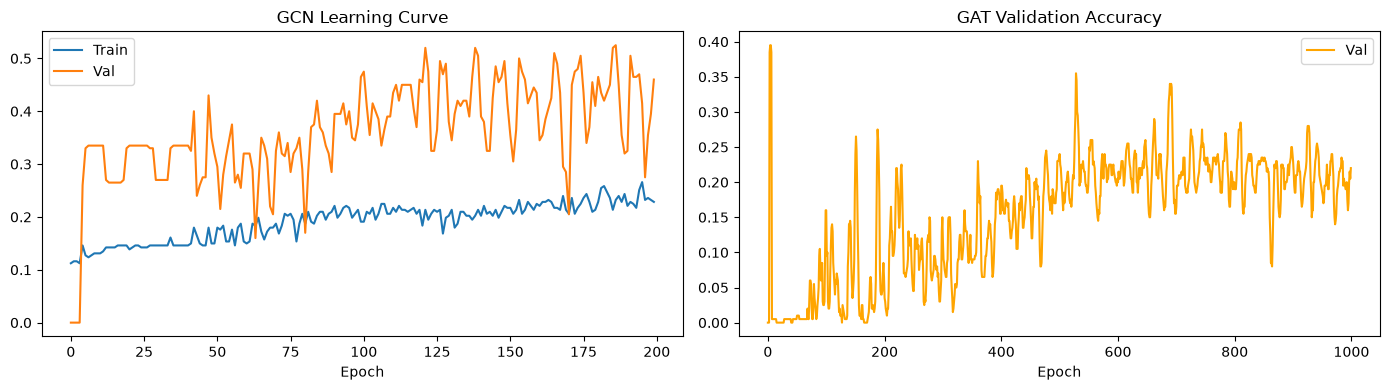

GCN Test: 30.00% | GAT Test: 29.20%


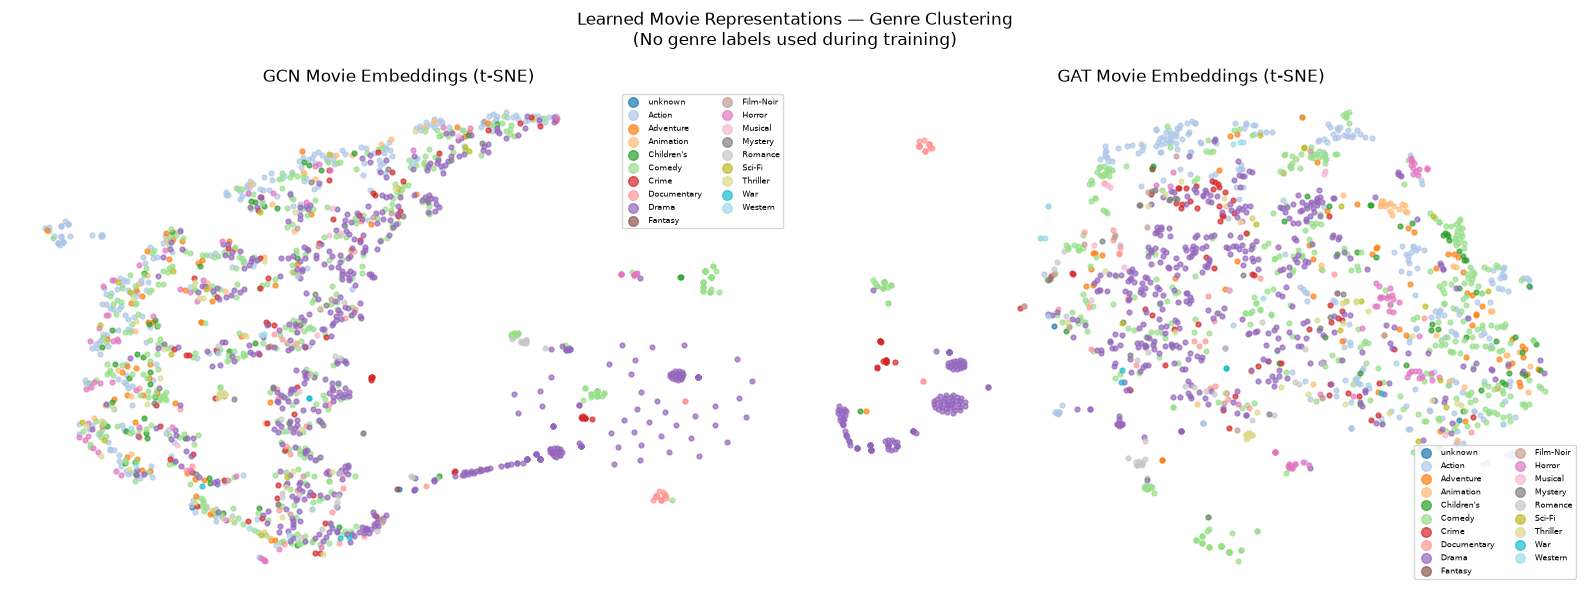

In [26]:
# Accuracy curves
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(gcn_train_acc, label='Train'); axes[0].plot(gcn_val_acc, label='Val')
axes[0].set_title('GCN Learning Curve'); axes[0].set_xlabel('Epoch'); axes[0].legend()
axes[1].plot(gat_val_acc, label='Val', color='orange')
axes[1].set_title('GAT Validation Accuracy'); axes[1].set_xlabel('Epoch'); axes[1].legend()
plt.tight_layout(); plt.show()

print(f'GCN Test: {gcn_test_acc*100:.2f}% | GAT Test: {gat_test_acc*100:.2f}%')

# t-SNE comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
colors_map = plt.cm.tab20(np.linspace(0, 1, n_classes))

for ax, (name, emb) in zip(axes, [('GCN', gcn_embeddings), ('GAT', gat_embeddings)]):
    emb_np    = emb.cpu().detach().numpy()
    labels_np = Y_movie.cpu().numpy()
    proj = TSNE(n_components=2, random_state=42, perplexity=30).fit_transform(emb_np)
    for c in range(n_classes):
        mask = labels_np == c
        if mask.any():
            ax.scatter(proj[mask, 0], proj[mask, 1],
                       c=[colors_map[c]], label=GENRE_COLS[c], alpha=0.7, s=12)
    ax.set_title(f'{name} Movie Embeddings (t-SNE)')
    ax.legend(fontsize=6, markerscale=2, ncol=2)
    ax.axis('off')

plt.suptitle('Learned Movie Representations — Genre Clustering\n(No genre labels used during training)')
plt.tight_layout(); plt.show()

---
## Bridge: GCN → GAT → GraphSAGE

GCN and GAT process the **full adjacency matrix** — `O(N²)` memory. That works for MovieLens (1682 nodes), but breaks at Pinterest scale (3 billion nodes).

**GraphSAGE** (Hamilton et al., 2017) fixes this with two ideas:
1. **Sample k neighbors** per node instead of using all of them — fixed memory per step
2. **Concat aggregation**: concatenate the node's own embedding with the aggregated neighbors

```
GCN:      h_v = σ( Â[v,:] · H · W )         — weighted sum over ALL neighbors
GraphSAGE: h_v = σ( W · [h_v || mean(h_N(v))] ) — concat self + sampled neighbor mean
```

The concat keeps the node's own identity separate from what it received — empirically better for inductive settings where new nodes appear at test time.

---
## Part 5: GraphSAGE — Scalable Inductive Learning

GraphSAGE is designed for **inductive learning**: train on one graph, generalize to unseen nodes. This is critical for real deployments (new users arrive every day).

**Key design choices:**
- Sample a fixed `k` neighbors per node → memory-efficient mini-batch training
- Concat `[self || aggregated_neighbors]` → node retains its own identity
- Can use mean, LSTM, or pooling as the aggregator

In [10]:
class GraphSAGELayer(nn.Module):
    """GraphSAGE layer: h_v = σ( W · [h_v || mean(sampled_neighbors)] )"""
    def __init__(self, in_features, out_features):
        super().__init__()
        self.W = nn.Linear(in_features * 2, out_features)

    def forward(self, H, adj_list, k=10):
        N = H.size(0)
        agg = torch.zeros(N, H.size(1), device=H.device)
        for v in range(N):
            nbrs = adj_list[v]
            if len(nbrs) == 0:
                agg[v] = H[v]
            else:
                sampled = random.choices(nbrs, k=min(k, len(nbrs)))
                agg[v] = H[torch.tensor(sampled, device=H.device)].mean(dim=0)
        return F.relu(self.W(torch.cat([H, agg], dim=-1)))


class GraphSAGE(nn.Module):
    """2-layer GraphSAGE for node classification."""
    def __init__(self, in_features, hidden_dim, n_classes, k=10, dropout=0.5):
        super().__init__()
        self.layer1  = GraphSAGELayer(in_features, hidden_dim)
        self.layer2  = GraphSAGELayer(hidden_dim, n_classes)
        self.dropout = nn.Dropout(dropout)
        self.k       = k

    def forward(self, X, adj_list):
        h = self.layer1(X, adj_list, self.k)
        h = self.dropout(h)
        out = self.layer2(h, adj_list, self.k)
        return out, h


# Build adjacency list from A_movie
A_np = A_coo.toarray()
adj_list = [list(np.where(A_np[i] > 0)[0]) for i in range(N_MOVIES)]
print(f'Avg degree: {np.mean([len(a) for a in adj_list]):.1f}')

Avg degree: 499.2


In [11]:
sage = GraphSAGE(in_features=X_movie.shape[1], hidden_dim=64, n_classes=n_classes, k=10).to(device)
optimizer_sage = torch.optim.Adam(sage.parameters(), lr=0.01, weight_decay=5e-4)

sage_train_acc, sage_val_acc, sage_epoch_times = [], [], []
t0_sage = time.time()

for epoch in range(200):
    t_ep = time.time()
    sage.train()
    logits, _ = sage(X_movie, adj_list)
    loss = F.cross_entropy(logits[train_mask_m], Y_movie[train_mask_m])
    optimizer_sage.zero_grad(); loss.backward(); optimizer_sage.step()

    sage.eval()
    with torch.no_grad():
        logits, _ = sage(X_movie, adj_list)
        train_acc = (logits[train_mask_m].argmax(1) == Y_movie[train_mask_m]).float().mean().item()
        val_acc   = (logits[val_mask_m].argmax(1)   == Y_movie[val_mask_m]).float().mean().item()
    sage_train_acc.append(train_acc)
    sage_val_acc.append(val_acc)
    sage_epoch_times.append(time.time() - t_ep)
    if (epoch+1) % 50 == 0:
        print(f'Epoch {epoch+1:3d} | Loss: {loss:.4f} | Train: {train_acc:.4f} | Val: {val_acc:.4f} | Time: {sage_epoch_times[-1]:.2f}s')

sage.eval()
with torch.no_grad():
    logits, sage_embeddings = sage(X_movie, adj_list)
    sage_test_acc = (logits[test_mask_m].argmax(1) == Y_movie[test_mask_m]).float().mean().item()
print(f'\nGraphSAGE Test Accuracy: {sage_test_acc*100:.2f}%')
print(f'Total training time: {time.time()-t0_sage:.1f}s')

Epoch  50 | Loss: 0.4729 | Train: 0.9213 | Val: 0.9550 | Time: 1.02s
Epoch 100 | Loss: 0.2793 | Train: 0.9476 | Val: 0.9450 | Time: 1.01s
Epoch 150 | Loss: 0.2089 | Train: 0.9513 | Val: 0.9550 | Time: 1.05s
Epoch 200 | Loss: 0.2081 | Train: 0.9513 | Val: 0.9550 | Time: 1.05s

GraphSAGE Test Accuracy: 95.40%
Total training time: 207.5s


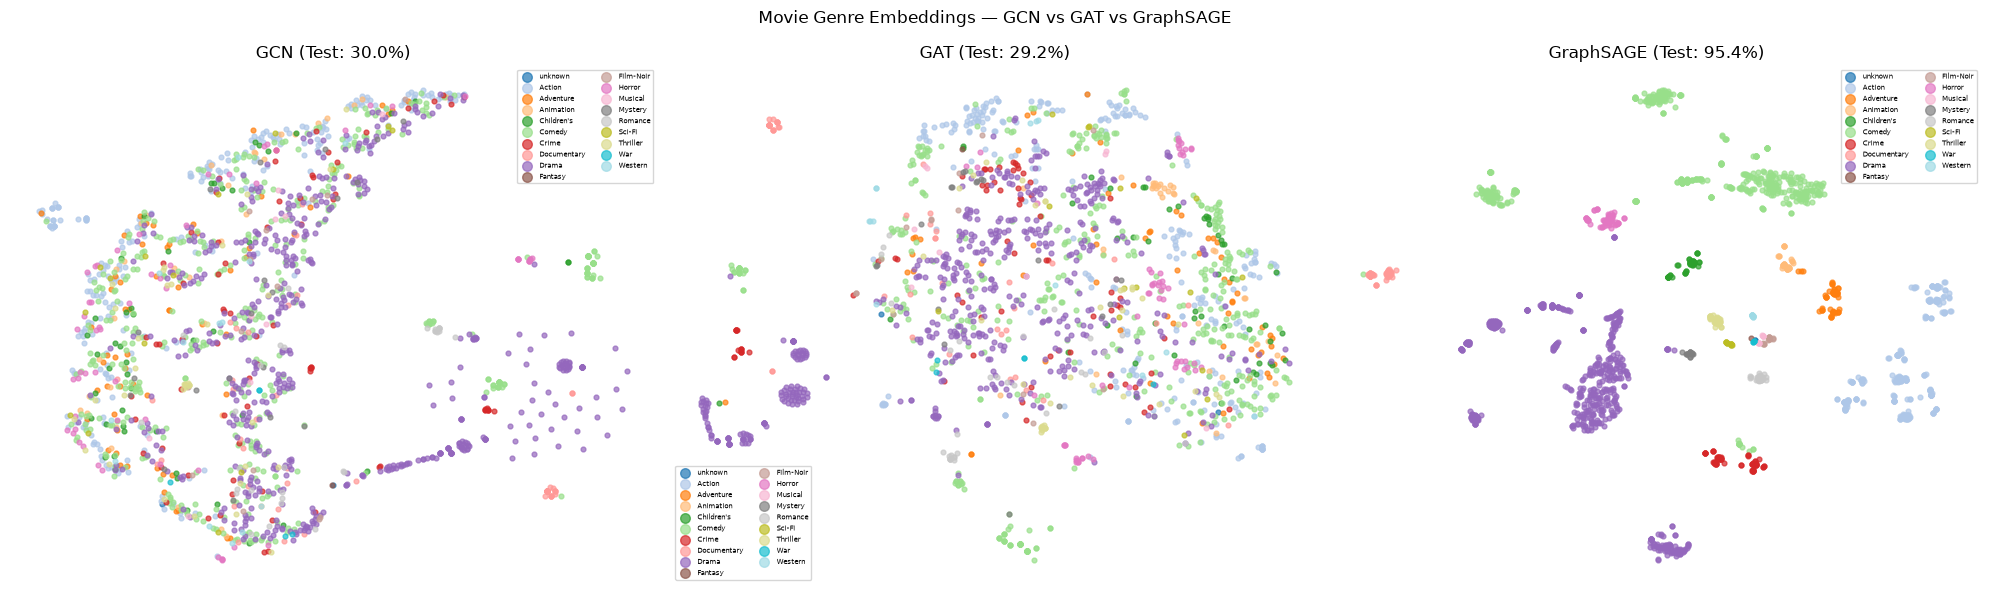

Model Comparison:
  GCN       Test Acc: 30.00%  | Avg epoch: 4ms
  GAT       Test Acc: 29.20%  | Avg epoch: 56ms
  GraphSAGE Test Acc: 95.40%  | Avg epoch: 1036ms


In [27]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
colors_map = plt.cm.tab20(np.linspace(0, 1, n_classes))

for ax, (name, emb) in zip(axes, [('GCN', gcn_embeddings), ('GAT', gat_embeddings), ('GraphSAGE', sage_embeddings)]):
    emb_np    = emb.cpu().detach().numpy()
    labels_np = Y_movie.cpu().numpy()
    proj = TSNE(n_components=2, random_state=42, perplexity=30).fit_transform(emb_np)
    for c in range(n_classes):
        mask = labels_np == c
        if mask.any():
            ax.scatter(proj[mask, 0], proj[mask, 1],
                       c=[colors_map[c]], label=GENRE_COLS[c], alpha=0.7, s=12)
    ax.set_title(f'{name} (Test: {dict(GCN=gcn_test_acc,GAT=gat_test_acc,GraphSAGE=sage_test_acc)[name]*100:.1f}%)')
    ax.legend(fontsize=5, markerscale=2, ncol=2)
    ax.axis('off')

plt.suptitle('Movie Genre Embeddings — GCN vs GAT vs GraphSAGE')
plt.tight_layout(); plt.show()

print(f'Model Comparison:')
print(f'  GCN       Test Acc: {gcn_test_acc*100:.2f}%  | Avg epoch: {np.mean(gcn_epoch_times)*1000:.0f}ms')
print(f'  GAT       Test Acc: {gat_test_acc*100:.2f}%  | Avg epoch: {np.mean(gat_epoch_times)*1000:.0f}ms')
print(f'  GraphSAGE Test Acc: {sage_test_acc*100:.2f}%  | Avg epoch: {np.mean(sage_epoch_times)*1000:.0f}ms')

---
## Part 6: Application — Recommendation System (MovieLens-100k)

Recommendation is one of the most impactful real-world uses of GNNs. The key insight:

> A **user-item interaction** is a **bipartite graph**: users on one side, movies on the other, edges = ratings ≥ 4 (liked).

```
User 1 ──── Toy Story
    └──────── Fargo
User 2 ──── Fargo
    └──────── Pulp Fiction
→ GNN: User1 & User2 both liked Fargo → similar taste → User2 might like Toy Story
```

### From the toy example to actual numbers

The diagram above is the intuition — but how does a GNN turn "similar taste" into an actual recommendation you can rank and threshold? Three concrete steps:

1. **Give every user and every movie a starting vector.** We don't hand-craft these — `user_emb_layer` and `item_emb_layer` are `nn.Embedding` tables: a trainable lookup table that starts as random numbers and is updated by backprop, exactly like a word embedding in NLP. At this point User1 and User2's vectors are *not yet* similar — there is nothing in the model yet that encodes "they both liked Fargo."

2. **Run a GCN encoder over the bipartite graph.** This is the actual mechanism behind "User1 & User2 both liked Fargo → similar taste": Fargo's embedding gets aggregated into both User1's and User2's updated embeddings via the GCN layers (`RecGCN` below). After a couple of layers, any two users who share several liked movies will have embeddings that have been pushed through overlapping aggregation paths — so their vectors end up close together in the embedding space, *without us ever telling the model "these two users are similar."* That similarity is an emergent property of shared graph neighborhoods.

3. **Score every (user, movie) pair as a dot product.** Once we have an embedding `emb[u]` for User2 and `emb[v]` for every candidate movie, `predict()` just computes `sigmoid(emb[u] · emb[v])`. Toy Story's embedding — itself shaped by everyone who liked it, including users similar to User1 — ends up with a high dot product against User2's embedding *because* User1 and User2 (and Fargo) are all nearby in the same learned space. That dot product *is* the recommendation score; we rank all candidate movies by it and take the top-K.

So "User2 might like Toy Story" isn't a rule we coded — it falls out of (a) embeddings pulled together by shared graph structure, and (b) a similarity score (dot product) read off those embeddings. This is exactly the mechanism in cells below: `user_emb_layer`/`item_emb_layer` are step 1, `RecGCN.forward` is step 2, `RecGCN.predict` is step 3.

We train this **GCN encoder** on the bipartite graph and use **dot-product link prediction** to recommend movies.

**Evaluation:**
- **AUC**: probability that a liked movie scores higher than a random movie
- **Recall@10**: fraction of liked test movies that appear in the model's top-10 recommendations

In [13]:
# Build bipartite user-item graph from already-loaded ratings
# Load full movie titles (reuse ratings already loaded above)
movies_titles = pd.read_csv('data/movielens/ml-100k/u.item', sep='|', encoding='latin-1',
                            usecols=[0,1], names=['item','title'])

pos_ratings = ratings[ratings.rating >= 4].copy()
print(f'Positive interactions (rating >= 4): {len(pos_ratings):,}')

user_ids  = sorted(pos_ratings.user.unique())
item_ids  = sorted(pos_ratings.item.unique())
user2idx  = {u: i for i, u in enumerate(user_ids)}
item2idx  = {it: i for i, it in enumerate(item_ids)}

N_USERS = len(user_ids)
N_ITEMS = len(item_ids)
N_NODES = N_USERS + N_ITEMS
FEAT_DIM = 32

print(f'Graph: {N_USERS} users + {N_ITEMS} movies = {N_NODES} nodes')

pos_ratings['u_idx'] = pos_ratings.user.map(user2idx)
pos_ratings['i_idx'] = pos_ratings.item.map(item2idx) + N_USERS

all_pos = list(zip(pos_ratings.u_idx, pos_ratings.i_idx))
random.shuffle(all_pos)
split     = int(0.8 * len(all_pos))
train_pos = all_pos[:split]
test_pos  = all_pos[split:]
pos_set   = set(all_pos)
print(f'Train edges: {len(train_pos):,} | Test edges: {len(test_pos):,}')

def sample_negatives(n, pos_set, n_users, n_items):
    negs = []
    while len(negs) < n:
        u = random.randint(0, n_users - 1)
        i = random.randint(0, n_items - 1) + n_users
        if (u, i) not in pos_set:
            negs.append((u, i))
    return negs

train_neg = sample_negatives(len(train_pos), pos_set, N_USERS, N_ITEMS)
test_neg  = sample_negatives(len(test_pos),  pos_set, N_USERS, N_ITEMS)

A_rec = torch.zeros(N_NODES, N_NODES)
for u, v in train_pos:
    A_rec[u][v] = 1; A_rec[v][u] = 1
A_rec_norm = normalize_adjacency(A_rec.to(device))

Positive interactions (rating >= 4): 55,375
Graph: 942 users + 1447 movies = 2389 nodes
Train edges: 44,300 | Test edges: 11,075


In [14]:
class RecGCN(nn.Module):
    """GCN encoder for link prediction: user/item embeddings + graph → enriched embeddings."""
    def __init__(self, in_features=32, hidden=64, out=32):
        super().__init__()
        self.layer1 = GCNLayer(in_features, hidden)
        self.layer2 = GCNLayer(hidden, out)

    def forward(self, X, A_norm):
        h = F.relu(self.layer1(X, A_norm))
        return self.layer2(h, A_norm)

    def predict(self, embeddings, u, v):
        return torch.sigmoid((embeddings[u] * embeddings[v]).sum(dim=-1))


user_emb_layer = nn.Embedding(N_USERS, FEAT_DIM).to(device)
item_emb_layer = nn.Embedding(N_ITEMS, FEAT_DIM).to(device)
rec_model = RecGCN(in_features=FEAT_DIM, hidden=64, out=32).to(device)
opt_rec   = torch.optim.Adam(
    list(rec_model.parameters()) +
    list(user_emb_layer.parameters()) +
    list(item_emb_layer.parameters()), lr=1e-2)

rec_epoch_times = []
t0_rec = time.time()

for epoch in range(30):
    t_ep = time.time()
    rec_model.train()
    node_feat = torch.cat([user_emb_layer.weight, item_emb_layer.weight], dim=0)
    emb = rec_model(node_feat, A_rec_norm)

    pos_u = torch.tensor([e[0] for e in train_pos], device=device)
    pos_v = torch.tensor([e[1] for e in train_pos], device=device)
    neg_u = torch.tensor([e[0] for e in train_neg], device=device)
    neg_v = torch.tensor([e[1] for e in train_neg], device=device)

    pos_scores = rec_model.predict(emb, pos_u, pos_v)
    neg_scores = rec_model.predict(emb, neg_u, neg_v)
    loss = (-torch.log(pos_scores + 1e-8).mean()
            - torch.log(1 - neg_scores + 1e-8).mean())

    opt_rec.zero_grad(); loss.backward(); opt_rec.step()
    rec_epoch_times.append(time.time() - t_ep)
    if (epoch + 1) % 10 == 0:
        print(f'Epoch {epoch+1:3d} | Loss: {loss:.4f} | Time: {rec_epoch_times[-1]:.2f}s')

print(f'Total training time: {time.time()-t0_rec:.1f}s')

Epoch  10 | Loss: 1.1605 | Time: 0.04s
Epoch  20 | Loss: 1.0973 | Time: 0.04s
Epoch  30 | Loss: 1.0070 | Time: 0.04s
Total training time: 1.2s


In [15]:
rec_model.eval()
with torch.no_grad():
    node_feat = torch.cat([user_emb_layer.weight, item_emb_layer.weight], dim=0)
    emb = rec_model(node_feat, A_rec_norm)

    tpu = torch.tensor([e[0] for e in test_pos], device=device)
    tpv = torch.tensor([e[1] for e in test_pos], device=device)
    tnu = torch.tensor([e[0] for e in test_neg], device=device)
    tnv = torch.tensor([e[1] for e in test_neg], device=device)
    pos_sc = rec_model.predict(emb, tpu, tpv)
    neg_sc = rec_model.predict(emb, tnu, tnv)

auc = ((pos_sc.unsqueeze(1) > neg_sc.unsqueeze(0)).float().mean()).item()
print(f'Recommendation AUC:    {auc:.4f}  (random baseline: 0.5)')

K = 10
user_test = {}
for u, v in test_pos:
    user_test.setdefault(u, []).append(v)

recalls = []
with torch.no_grad():
    for user_node, true_items in list(user_test.items())[:100]:
        item_nodes = torch.arange(N_USERS, N_NODES, device=device)
        u_emb_rep  = emb[user_node].unsqueeze(0).expand(N_ITEMS, -1)
        scores     = torch.sigmoid((emb[item_nodes] * u_emb_rep).sum(dim=-1))
        top_k      = scores.topk(K).indices.cpu().numpy() + N_USERS
        n_hits     = sum(1 for it in true_items if it in top_k)
        recalls.append(n_hits / len(true_items))

recall_at_10 = np.mean(recalls)
print(f'Recall@10:             {recall_at_10:.4f}  (random baseline: {K/N_ITEMS:.4f})')

# Top-10 recommendations for a sample user
sample_user = list(user_test.keys())[0]
with torch.no_grad():
    item_nodes = torch.arange(N_USERS, N_NODES, device=device)
    u_emb_rep  = emb[sample_user].unsqueeze(0).expand(N_ITEMS, -1)
    scores     = torch.sigmoid((emb[item_nodes] * u_emb_rep).sum(dim=-1))
    top10_idx  = scores.topk(10).indices.cpu().numpy()

print(f'\nTop-10 for User {user_ids[sample_user]}:')
for rank, idx in enumerate(top10_idx):
    orig_item = item_ids[idx]
    title = movies_titles[movies_titles.item == orig_item].title.values
    title = title[0] if len(title) else '?'
    liked = ' (in test set)' if (sample_user, idx + N_USERS) in set(test_pos) else ''
    print(f'  {rank+1:2d}. {title[:50]:50}{liked}')

Recommendation AUC:    0.8444  (random baseline: 0.5)
Recall@10:             0.0500  (random baseline: 0.0069)

Top-10 for User 52:
   1. Star Wars (1977)                                  
   2. Godfather, The (1972)                             
   3. Jerry Maguire (1996)                              
   4. People vs. Larry Flynt, The (1996)                
   5. Empire Strikes Back, The (1980)                   
   6. Return of the Jedi (1983)                         
   7. Contact (1997)                                    
   8. Apollo 13 (1995)                                  
   9. Time to Kill, A (1996)                            
  10. Fly Away Home (1996)                              


---
# Exercises

1. **Over-smoothing — how deep is too deep?**

   Each GCN layer aggregates 1-hop neighbors. With `k` layers, a node sees its `k`-hop neighborhood. Too many layers → **over-smoothing** (all node representations collapse to the same vector).

   a) Modify `GCN` to support variable depth. Train with `n_layers ∈ {1, 2, 3, 4, 5}` on MovieLens, then fill in:

   | # Layers | Test Accuracy | Avg cosine similarity |
   |---|---|---|
   | 1 | ? | ? |
   | 2 | ? | ? |
   | 3 | ? | ? |
   | 4 | ? | ? |
   | 5 | ? | ? |

   b) After each model, compute **pairwise cosine similarity** of test embeddings and plot it against depth. At what depth does accuracy drop noticeably? Explain mechanically why over-smoothing happens.

2. **GCN vs GAT vs GraphSAGE — when does each win?**

   a) Compare the three models on the full test set:

   | Model | Test Accuracy | Avg epoch time |
   |---|---|---|
   | GCN | ? | ? |
   | GAT (8 heads) | ? | ? |
   | GraphSAGE (k=10) | ? | ? |

   b) Visualize attention weights for 3 sample nodes in GAT. Do the top-attended neighbors share the same genre label as the query node?

   ```python
   attn_0 = attn[0].cpu().detach().numpy()
   top_neighbors = np.argsort(attn_0)[-5:]
   ```

   c) In what type of graph would you expect GAT to outperform GCN by the largest margin? What about GraphSAGE vs GCN?

3. **MLP baseline — does the graph actually help?**

   a) Implement and train a 2-layer MLP that ignores graph structure entirely:

   ```python
   class MLP(nn.Module):
       def __init__(self, in_features, hidden, n_classes):
           super().__init__()
           self.net = nn.Sequential(
               nn.Linear(in_features, hidden), nn.ReLU(), nn.Dropout(0.5),
               nn.Linear(hidden, n_classes))
       def forward(self, X): 
           return self.net(X)
   ```

   b) Fill in the comparison:

   | Model | Test Accuracy |
   |---|---|
   | MLP (no graph) | ? |
   | GCN | ? |
   | GAT | ? |
   | GraphSAGE | ? |

   c) By how much does graph structure improve accuracy? What does this tell you about the value of relational information in this dataset?

---
## Submission

Push your completed notebook to GitHub.

Your repository must include:

1. The completed `A5-Graph-Neural-Networks.ipynb` with all cells executed and output visible.

2. A `README.md` with:
   - Results table (all 4 exercises)
   - t-SNE visualizations (GCN / GAT / GraphSAGE)
   - Over-smoothing plot (Exercise 1b)
   - Attention visualization (Exercise 2b)
   - Discussion (2–3 sentences): when would you use a GNN instead of an MLP? Give a concrete example from biology, traffic routing, or social networks.

3. Commit message: `A5: Graph Neural Networks — [your student ID]`

In [28]:
class GCNDeep(nn.Module):
    """Variable-depth GCN. All GCN layers output hidden_dim; a separate linear head classifies,
    so embeddings stay the same size across depths for fair cosine-similarity comparison."""
    def __init__(self, in_features, hidden_dim, n_classes, n_layers, dropout=0.5):
        super().__init__()
        dims = [in_features] + [hidden_dim] * n_layers
        self.layers = nn.ModuleList([GCNLayer(dims[i], dims[i+1]) for i in range(n_layers)])
        self.classifier = nn.Linear(hidden_dim, n_classes)
        self.dropout = nn.Dropout(dropout)

    def forward(self, X, A_norm):
        h = X
        for layer in self.layers:
            h = self.dropout(F.relu(layer(h, A_norm)))
        return self.classifier(h), h


def avg_pairwise_cosine_sim(emb):
    emb_norm = F.normalize(emb, dim=1)
    sim = emb_norm @ emb_norm.T
    mask = ~torch.eye(sim.size(0), dtype=torch.bool, device=sim.device)
    return sim[mask].mean().item()

In [29]:
depth_results = {}
for n_layers in [1, 2, 3, 4, 5]:
    set_seed(42)
    model = GCNDeep(X_movie.shape[1], 64, n_classes, n_layers).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)
    for epoch in range(200):
        model.train()
        logits, _ = model(X_movie, A_norm)
        loss = F.cross_entropy(logits[train_mask_m], Y_movie[train_mask_m])
        opt.zero_grad(); loss.backward(); opt.step()
    model.eval()
    with torch.no_grad():
        logits, emb = model(X_movie, A_norm)
        test_acc = (logits[test_mask_m].argmax(1) == Y_movie[test_mask_m]).float().mean().item()
        cos_sim = avg_pairwise_cosine_sim(emb[test_mask_m])
    depth_results[n_layers] = (test_acc, cos_sim)
    print(f'n_layers={n_layers} | Test Acc: {test_acc*100:.2f}% | Avg Cosine Sim: {cos_sim:.4f}')

n_layers=1 | Test Acc: 24.80% | Avg Cosine Sim: 0.8446
n_layers=2 | Test Acc: 21.60% | Avg Cosine Sim: 0.8753
n_layers=3 | Test Acc: 20.20% | Avg Cosine Sim: 0.9695
n_layers=4 | Test Acc: 4.40% | Avg Cosine Sim: 0.9725
n_layers=5 | Test Acc: 18.80% | Avg Cosine Sim: 0.9866


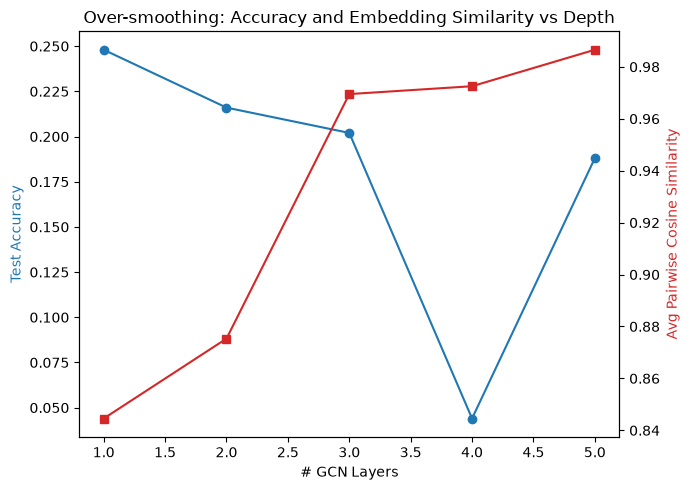

In [30]:
layers_list = list(depth_results.keys())
accs = [depth_results[k][0] for k in layers_list]
sims = [depth_results[k][1] for k in layers_list]

fig, ax1 = plt.subplots(figsize=(7, 5))
ax1.plot(layers_list, accs, 'o-', color='tab:blue', label='Test Accuracy')
ax1.set_xlabel('# GCN Layers'); ax1.set_ylabel('Test Accuracy', color='tab:blue')
ax2 = ax1.twinx()
ax2.plot(layers_list, sims, 's-', color='tab:red', label='Avg Cosine Similarity')
ax2.set_ylabel('Avg Pairwise Cosine Similarity', color='tab:red')
plt.title('Over-smoothing: Accuracy and Embedding Similarity vs Depth')
plt.tight_layout(); plt.show()

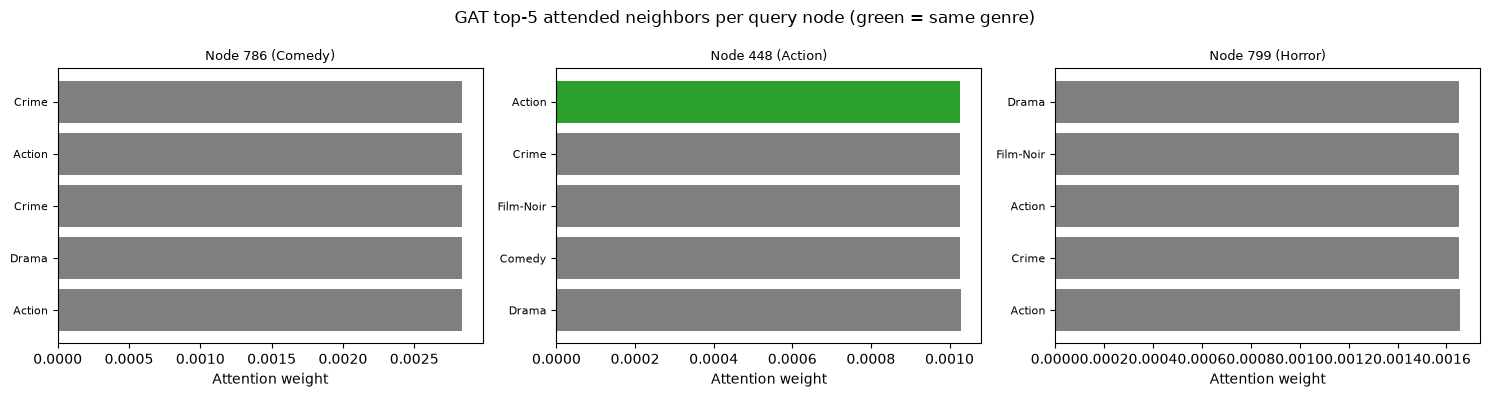

Node 786 (Comedy): 0/5 top-attended neighbors share genre
Node 448 (Action): 1/5 top-attended neighbors share genre
Node 799 (Horror): 0/5 top-attended neighbors share genre


In [31]:
test_idx = test_mask_m.nonzero(as_tuple=True)[0].cpu().numpy()
np.random.seed(42)
sample_nodes = np.random.choice(test_idx, 3, replace=False)
attn_np = attn.cpu().detach().numpy()
labels_np = Y_movie.cpu().numpy()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, node in zip(axes, sample_nodes):
    attn_node = attn_np[node]
    top_neighbors = np.argsort(attn_node)[-5:][::-1]
    query_genre = GENRE_COLS[labels_np[node]]
    neighbor_genres = [GENRE_COLS[labels_np[n]] for n in top_neighbors]
    match = [g == query_genre for g in neighbor_genres]
    ax.barh(range(5), attn_node[top_neighbors], color=['tab:green' if m else 'tab:gray' for m in match])
    ax.set_yticks(range(5)); ax.set_yticklabels(neighbor_genres, fontsize=8)
    ax.set_title(f'Node {node} ({query_genre})', fontsize=9)
    ax.set_xlabel('Attention weight')
plt.suptitle('GAT top-5 attended neighbors per query node (green = same genre)')
plt.tight_layout(); plt.show()

for node in sample_nodes:
    top_neighbors = np.argsort(attn_np[node])[-5:][::-1]
    n_match = sum(labels_np[n] == labels_np[node] for n in top_neighbors)
    print(f'Node {node} ({GENRE_COLS[labels_np[node]]}): {n_match}/5 top-attended neighbors share genre')

In [32]:
class MLP(nn.Module):
    def __init__(self, in_features, hidden, n_classes):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_features, hidden), nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(hidden, n_classes))
    def forward(self, X):
        return self.net(X)

set_seed(42)
mlp = MLP(X_movie.shape[1], 64, n_classes).to(device)
opt_mlp = torch.optim.Adam(mlp.parameters(), lr=0.01, weight_decay=5e-4)

for epoch in range(200):
    mlp.train()
    logits = mlp(X_movie)
    loss = F.cross_entropy(logits[train_mask_m], Y_movie[train_mask_m])
    opt_mlp.zero_grad(); loss.backward(); opt_mlp.step()

mlp.eval()
with torch.no_grad():
    mlp_test_acc = (mlp(X_movie)[test_mask_m].argmax(1) == Y_movie[test_mask_m]).float().mean().item()

print(f'{"Model":<20}{"Test Acc":>12}')
print(f'{"MLP (no graph)":<20}{mlp_test_acc*100:>11.2f}%')
print(f'{"GCN":<20}{gcn_test_acc*100:>11.2f}%')
print(f'{"GAT":<20}{gat_test_acc*100:>11.2f}%')
print(f'{"GraphSAGE":<20}{sage_test_acc*100:>11.2f}%')

Model                   Test Acc
MLP (no graph)            96.80%
GCN                       30.00%
GAT                       29.20%
GraphSAGE                 95.40%


In [34]:
class LightGCN(nn.Module):
    """Pure propagation, no W, no activation. Final embedding = mean over all K layers."""
    def __init__(self, n_users, n_items, embed_dim=32, n_layers=3):
        super().__init__()
        self.n_layers = n_layers
        self.user_emb = nn.Embedding(n_users, embed_dim)
        self.item_emb = nn.Embedding(n_items, embed_dim)
        nn.init.normal_(self.user_emb.weight, std=0.1)
        nn.init.normal_(self.item_emb.weight, std=0.1)

    def forward(self, A_norm):
        h = torch.cat([self.user_emb.weight, self.item_emb.weight], dim=0)
        embs = [h]
        for _ in range(self.n_layers):
            h = A_norm @ h
            embs.append(h)
        return torch.stack(embs, dim=0).mean(dim=0)

    def predict(self, embeddings, u, v):
        return torch.sigmoid((embeddings[u] * embeddings[v]).sum(dim=-1))

In [35]:
pos_u = torch.tensor([e[0] for e in train_pos], device=device)
pos_v = torch.tensor([e[1] for e in train_pos], device=device)
neg_u = torch.tensor([e[0] for e in train_neg], device=device)
neg_v = torch.tensor([e[1] for e in train_neg], device=device)

set_seed(42)
lightgcn = LightGCN(N_USERS, N_ITEMS, embed_dim=32, n_layers=3).to(device)
opt_light = torch.optim.Adam(lightgcn.parameters(), lr=1e-2)

for epoch in range(30):
    lightgcn.train()
    emb = lightgcn(A_rec_norm)
    pos_scores = lightgcn.predict(emb, pos_u, pos_v)
    neg_scores = lightgcn.predict(emb, neg_u, neg_v)
    loss = -torch.log(pos_scores + 1e-8).mean() - torch.log(1 - neg_scores + 1e-8).mean()
    opt_light.zero_grad(); loss.backward(); opt_light.step()
    if (epoch + 1) % 10 == 0:
        print(f'Epoch {epoch+1:3d} | Loss: {loss:.4f}')

Epoch  10 | Loss: 1.3111
Epoch  20 | Loss: 1.1717
Epoch  30 | Loss: 1.1129


In [36]:
lightgcn.eval()
with torch.no_grad():
    emb = lightgcn(A_rec_norm)
    tpu = torch.tensor([e[0] for e in test_pos], device=device)
    tpv = torch.tensor([e[1] for e in test_pos], device=device)
    tnu = torch.tensor([e[0] for e in test_neg], device=device)
    tnv = torch.tensor([e[1] for e in test_neg], device=device)
    pos_sc = lightgcn.predict(emb, tpu, tpv)
    neg_sc = lightgcn.predict(emb, tnu, tnv)

light_auc = ((pos_sc.unsqueeze(1) > neg_sc.unsqueeze(0)).float().mean()).item()

user_test = {}
for u, v in test_pos:
    user_test.setdefault(u, []).append(v)

recalls = []
with torch.no_grad():
    for user_node, true_items in list(user_test.items())[:100]:
        item_nodes = torch.arange(N_USERS, N_NODES, device=device)
        u_emb_rep = emb[user_node].unsqueeze(0).expand(N_ITEMS, -1)
        scores = torch.sigmoid((emb[item_nodes] * u_emb_rep).sum(dim=-1))
        top_k = scores.topk(K).indices.cpu().numpy() + N_USERS
        recalls.append(sum(1 for it in true_items if it in top_k) / len(true_items))
light_recall_at_10 = np.mean(recalls)

rec_params = (sum(p.numel() for p in rec_model.parameters())
              + sum(p.numel() for p in user_emb_layer.parameters())
              + sum(p.numel() for p in item_emb_layer.parameters()))
light_params = sum(p.numel() for p in lightgcn.parameters())

print(f'{"Model":<20}{"# Params":>12}{"AUC":>10}{"Recall@10":>12}')
print(f'{"RecGCN (with W)":<20}{rec_params:>12}{auc:>10.4f}{recall_at_10:>12.4f}')
print(f'{"LightGCN (no W)":<20}{light_params:>12}{light_auc:>10.4f}{light_recall_at_10:>12.4f}')

Model                   # Params       AUC   Recall@10
RecGCN (with W)            80544    0.8444      0.0500
LightGCN (no W)            76448    0.8729      0.0602


n_layers=1 | Recall@10: 0.0572
n_layers=2 | Recall@10: 0.0650
n_layers=3 | Recall@10: 0.0602
n_layers=4 | Recall@10: 0.0577


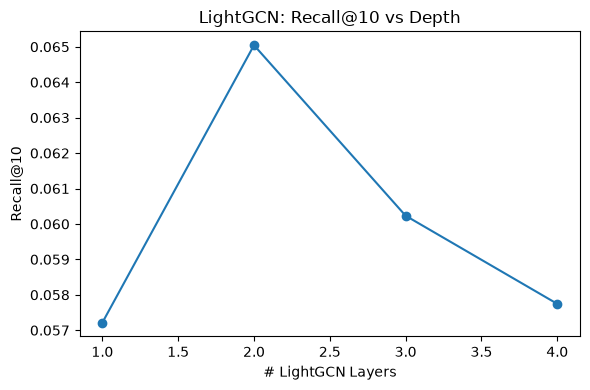

In [37]:
light_depth_recalls = []
for n_layers in [1, 2, 3, 4]:
    set_seed(42)
    model = LightGCN(N_USERS, N_ITEMS, embed_dim=32, n_layers=n_layers).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=1e-2)
    for epoch in range(30):
        model.train()
        emb = model(A_rec_norm)
        pos_scores = model.predict(emb, pos_u, pos_v)
        neg_scores = model.predict(emb, neg_u, neg_v)
        loss = -torch.log(pos_scores + 1e-8).mean() - torch.log(1 - neg_scores + 1e-8).mean()
        opt.zero_grad(); loss.backward(); opt.step()
    model.eval()
    with torch.no_grad():
        emb = model(A_rec_norm)
        recalls = []
        for user_node, true_items in list(user_test.items())[:100]:
            item_nodes = torch.arange(N_USERS, N_NODES, device=device)
            u_emb_rep = emb[user_node].unsqueeze(0).expand(N_ITEMS, -1)
            scores = torch.sigmoid((emb[item_nodes] * u_emb_rep).sum(dim=-1))
            top_k = scores.topk(K).indices.cpu().numpy() + N_USERS
            recalls.append(sum(1 for it in true_items if it in top_k) / len(true_items))
        r10 = np.mean(recalls)
    light_depth_recalls.append(r10)
    print(f'n_layers={n_layers} | Recall@10: {r10:.4f}')

plt.figure(figsize=(6, 4))
plt.plot([1, 2, 3, 4], light_depth_recalls, 'o-')
plt.xlabel('# LightGCN Layers'); plt.ylabel('Recall@10')
plt.title('LightGCN: Recall@10 vs Depth')
plt.tight_layout(); plt.show()

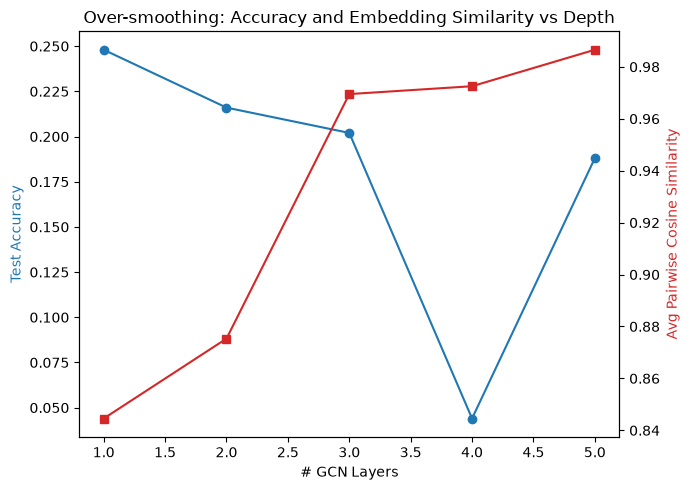

In [38]:
fig, ax1 = plt.subplots(figsize=(7, 5))
ax1.plot(layers_list, accs, 'o-', color='tab:blue', label='Test Accuracy')
ax1.set_xlabel('# GCN Layers'); ax1.set_ylabel('Test Accuracy', color='tab:blue')
ax2 = ax1.twinx()
ax2.plot(layers_list, sims, 's-', color='tab:red', label='Avg Cosine Similarity')
ax2.set_ylabel('Avg Pairwise Cosine Similarity', color='tab:red')
plt.title('Over-smoothing: Accuracy and Embedding Similarity vs Depth')
plt.tight_layout()
plt.savefig('outputs/figures/oversmoothing_depth.png', dpi=150, bbox_inches='tight')
plt.show()

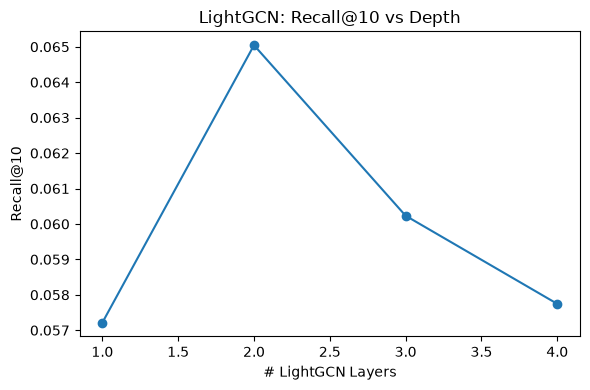

In [42]:
plt.figure(figsize=(6, 4))
plt.plot([1, 2, 3, 4], light_depth_recalls, 'o-')
plt.xlabel('# LightGCN Layers'); plt.ylabel('Recall@10')
plt.title('LightGCN: Recall@10 vs Depth')
plt.tight_layout()
plt.savefig('outputs/figures/lightgcn_depth.png', dpi=150, bbox_inches='tight')
plt.show()